In [1]:
import pytorch_lightning as pl
from pytorch_lightning import Trainer, loggers
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn.functional as F
from torch.optim.lr_scheduler import StepLR

from transformer_lens import HookedTransformer, HookedTransformerConfig, utils
from pathlib import Path
from pytorch_lightning.loggers import TensorBoardLogger
import os

from scipy.linalg import norm
from transformer_lens import HookedTransformer, HookedTransformerConfig, utils
import torch
import numpy as np
import plotly.express as px
import plotly.io as pio
from jaxtyping import Float, Int # Read about this library
import tqdm.auto as tqdm
import einops
from transformer_lens.utils import to_numpy
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
from datetime import datetime
# import pytorch_lightning as pl
from functools import partial
import pandas as pd

from transformer_lens.hook_points import (
    HookedRootModule,
    HookPoint,
)  # Hooking utilities

# Utils
def line(tensor, line_labels=None, yaxis="", xaxis="", title="", legend_title="", **kwargs):
    tensor = to_numpy(tensor)
    fig = px.line(tensor, **kwargs)

    showlegend=True if legend_title != "" else False

    # Update labels explicitly for x-axis and y-axis
    fig.update_layout(
        title=title,
        xaxis_title=xaxis,  # Set x-axis label
        yaxis_title=yaxis,  # Set y-axis label
        height=400,  # Optional: maintain height for consistency
        showlegend=showlegend,
        legend_title=legend_title  # Set legend title
    )
    
    # Apply line labels if provided
    if line_labels:
        for c, label in enumerate(line_labels):
            fig.data[c].name = label
    
    fig.show()

    

def imshow(tensor, yaxis="", xaxis="", **kwargs):
    tensor = to_numpy(tensor)
    plot_kwargs = {
        "color_continuous_scale": "RdBu",
        "color_continuous_midpoint": 0.0,
        "labels": {"x": xaxis, "y": yaxis},
    }
    plot_kwargs.update(kwargs)
    px.imshow(tensor, **plot_kwargs).show()

# Load trained model

In [2]:
device='cpu'
def deactivate_position(model):
    model.pos_embed.W_pos.data[:] = 0.0
    model.pos_embed.W_pos.requires_grad = False

def freeze_embeddings(model):
    model.embed.W_E.requires_grad = False

def freeze_attention(model, l=0):
    model.blocks[l].attn.W_Q.requires_grad = False
    model.blocks[l].attn.W_K.requires_grad = False
    model.blocks[l].attn.W_V.requires_grad = False
    model.blocks[l].attn.W_O.requires_grad = False

    model.blocks[l].attn.b_Q.requires_grad = False
    model.blocks[l].attn.b_K.requires_grad = False
    model.blocks[l].attn.b_V.requires_grad = False
    model.blocks[l].attn.b_O.requires_grad = False


class LitTransformer(pl.LightningModule):
    def __init__(self, config, train_dataloader, val_dataloader):
        super().__init__()
        self.model = HookedTransformer(config)
        self.model.to(device)
        deactivate_position(self.model)
        freeze_embeddings(self.model)
        freeze_attention(self.model, l=0)
        # print(self.model.pos_embed.W_pos.data)
        # print(self.model.blocks[0].attn.W_Q.data)
        # print(self.model.W_E.device)
        self._train_dataloader = train_dataloader
        self._val_dataloader = val_dataloader

    def forward(self, tokens):
        return self.model(tokens.to(device))

    def training_step(self, batch, batch_idx):
        tokens, targets = batch
        tokens = tokens.to(device)
        targets = targets .to(device)
        logits = self(tokens)
        loss = self.loss_fn(logits, targets)
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        tokens, targets = batch
        logits = self(tokens)
        loss = self.loss_fn(logits, targets)
        self.log('val_loss', loss)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=5e-5, betas=(0.9, 0.95), weight_decay=0.1)
        scheduler = StepLR(optimizer, step_size=100, gamma=0.1)
        return [optimizer], [scheduler]

    def train_dataloader(self):
        return self._train_dataloader

    def val_dataloader(self):
        return self._val_dataloader

    def loss_fn(self, logits, labels, per_token=False):
        log_probs = logits.log_softmax(-1)
        correct_log_probs = log_probs.gather(-1, labels[..., None])[..., 0]
        if per_token:
            return -correct_log_probs
        else:
            return -correct_log_probs.mean()
################ Data
class CustomDataset(TensorDataset):
    def __init__(self, tokens, targets):
        super().__init__(tokens, targets)
BASE = Path('.').resolve() 
N_CTX = 64
TRAIN_RATIO = 0.8
TBLOGSDIR = f'tblogs'
D_VOCAB = 1_024
D_MODEL = 2048
N_SAMPLES = D_VOCAB*10
BATCH_SIZE = N_SAMPLES 
EMB_STD = 0.025

train_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)
test_dataset = torch.randint(low=0, high=D_VOCAB, size=(N_SAMPLES, N_CTX), device=device)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

################ Data
cfg = HookedTransformerConfig(
    n_layers=1,
    d_model=D_MODEL,
    d_head=D_MODEL,
    n_heads=1,
    d_mlp=D_MODEL*4,
    d_vocab=D_VOCAB,
    n_ctx=N_CTX,
    act_fn='relu',
    normalization_type='LNPre',
    device=device,
    use_hook_mlp_in=True
)
def update_embedding(x):
    import torch.nn as nn
    std = np.sqrt(1.0 / (x.shape[1]))
    return nn.init.normal_(x, mean=0.0, std=std)

lit_model = LitTransformer(cfg, train_loader, test_loader)
lit_model.to(device)
model = lit_model.model

Moving model to device:  cpu


In [3]:
model.embed.W_E.data.std()

tensor(0.0177)

In [4]:
model.blocks[0].attn.W_Q.data.std()

tensor(0.0177)

In [ ]:
# update_embedding(model.embed.W_E)

Parameter containing:
tensor([[ 0.0309,  0.0300, -0.0018,  ..., -0.0454,  0.0119,  0.0153],
        [-0.0228,  0.0335, -0.0261,  ...,  0.0156,  0.0157,  0.0011],
        [-0.0158, -0.0331,  0.0108,  ...,  0.0048,  0.0204,  0.0117],
        ...,
        [-0.0168, -0.0139,  0.0162,  ...,  0.0528, -0.0059, -0.0117],
        [-0.0107,  0.0052,  0.0243,  ..., -0.0397, -0.0304,  0.0226],
        [ 0.0111, -0.0423, -0.0345,  ..., -0.0210, -0.0014, -0.0147]])

In [5]:
model.embed.W_E.data.std()

tensor(0.0177)

In [6]:
model.blocks[0].attn.W_Q.data.std()

tensor(0.0177)

In [ ]:
logits, cache = model.run_with_cache(test_loader.dataset)
logits.shape

In [121]:
# L0
n_layers = 1
for layer_id in range(n_layers):
    # Heads
    for i in range(cfg.n_heads):
        imshow(
            (np.exp(cache[f"blocks.{layer_id}.attn.hook_attn_scores"][:, i, :, :].mean([0]).cpu().numpy())),
            title=f"Layer {layer_id} Attention Pattern {i}",
            height=500,
            width=500,
        )

In [122]:
# L0
n_layers = 1
for layer_id in range(n_layers):
    # Heads
    for i in range(cfg.n_heads):
        imshow(
            to_numpy(cache["attn", layer_id][:, [i], :, :].mean([0, 1])),
            # title=f"Layer {layer_id} Attention Pattern {i}",
            height=500,
            width=500,
        )

In [123]:
line(cache['blocks.0.attn.hook_pattern'].mean(0).squeeze(0).var(-1), xaxis='Position', yaxis='Variance')

In [124]:
line(cache['blocks.0.attn.hook_pattern'][0].squeeze(0).var(-1), xaxis='Position', yaxis='Variance')

# Working cell

# q=0.1

Activations shape: (10240, 64, 1024)
0.22519055753946307 -0.22319293767213821


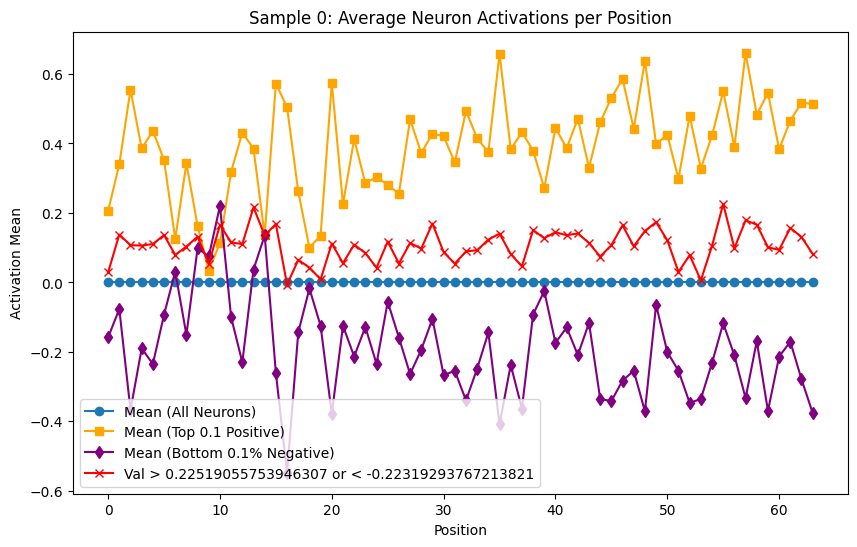

Plotted sample 0


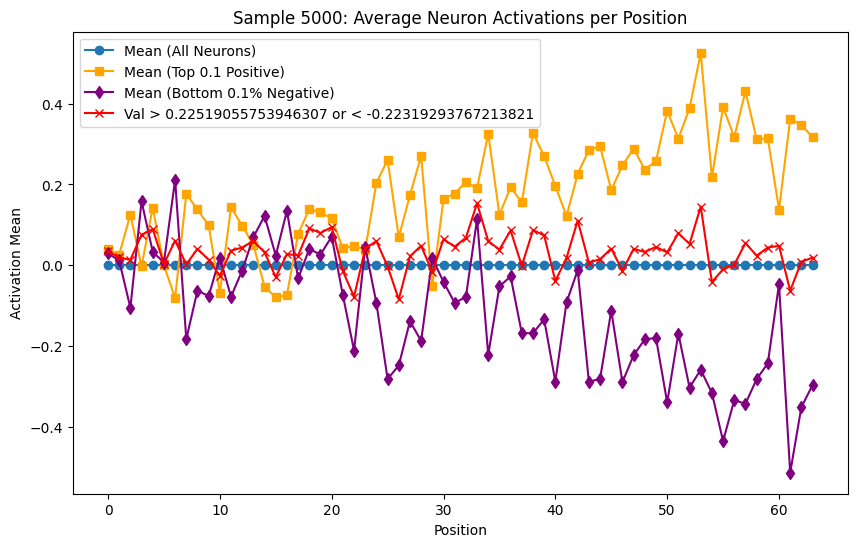

Plotted sample 5000


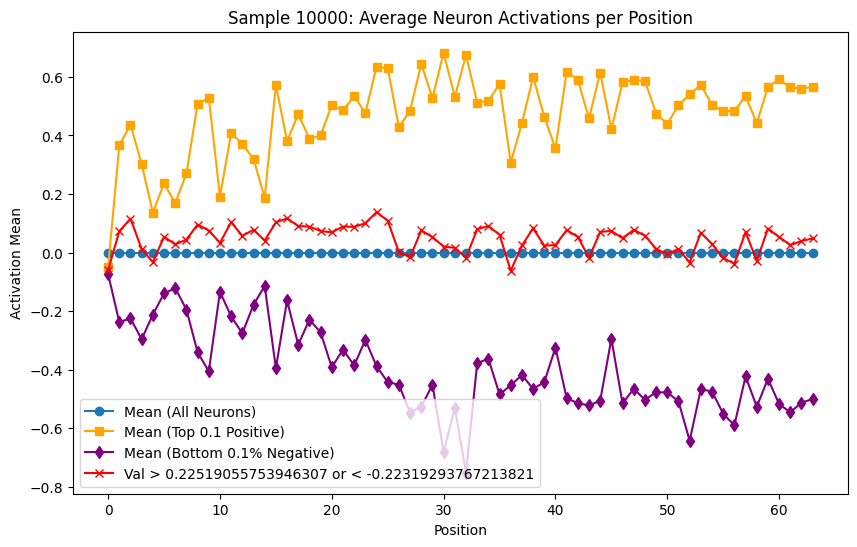

Plotted sample 10000


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1):
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    neurons_mean_val = X.mean(axis=0) 
    positive_neurons =  neurons_mean_val[neurons_mean_val>0]
    negative_neurons =  neurons_mean_val[neurons_mean_val<0]
    top_10_percent = np.quantile(positive_neurons, 1-q) # Returns a scalar
    bottom_10_percent = np.quantile(negative_neurons, q)
    print(top_10_percent, bottom_10_percent)
    avg_top10_neurons_mask = neurons_mean_val>top_10_percent
    avg_bottom10_neurons_mask = neurons_mean_val<bottom_10_percent
    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_mod = []          # Mean over neurons with |x| in [lower_thresh, upper_thresh]
        avg_pos_mod = []      # Mean over positive neurons in moderate range.
        avg_neg_mod = []      # Mean over negative neurons in moderate range.
        avg_top_q_pos = []   # Mean over top 30% positive neurons.
        avg_bottom_q_neg = []  # Mean over bottom 30% negative neurons.
        avg_abs_in_q = []

        for pos_vec in sample:
            position_top10neurons_avg = pos_vec[avg_top10_neurons_mask].mean()
            position_bottom10neurons_avg =  pos_vec[avg_bottom10_neurons_mask].mean()
            abs_in_q =  pos_vec[avg_top10_neurons_mask | avg_bottom10_neurons_mask].mean()

            avg_all.append(pos_vec.mean())
            avg_top_q_pos.append(position_top10neurons_avg)
            avg_bottom_q_neg.append(position_bottom10neurons_avg)
            avg_abs_in_q.append(abs_in_q)

        avg_all = np.array(avg_all)
        # avg_mod = np.array(avg_mod)
        # avg_pos_mod = np.array(avg_pos_mod)
        # avg_neg_mod = np.array(avg_neg_mod)
        avg_top_q_pos = np.array(avg_top_q_pos)
        avg_bottom_q_neg = np.array(avg_bottom_q_neg)
        avg_abs_in_q = np.array(avg_abs_in_q)
    
        if i % 5_000 == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            # plt.plot(positions, avg_pos_mod, marker='^', label='Mean (Positive Moderates)')
            # plt.plot(positions, avg_neg_mod, marker='v', label='Mean (Negative Moderates)')
            plt.plot(positions, avg_top_q_pos, marker='s', label=f'Mean (Top {q} Positive)', color='orange')
            plt.plot(positions, avg_bottom_q_neg, marker='d', label=f'Mean (Bottom {q}% Negative)', color='purple')
            plt.plot(positions, avg_abs_in_q, marker='x', label=f'Val > {top_10_percent} or < {bottom_10_percent}', color='red')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()
            plt.show()
            print(f"Plotted sample {i}")

# Example call:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1)

# q = 0.2

Activations shape: (10240, 64, 1024)
0.1853559285402298 -0.1830282360315323


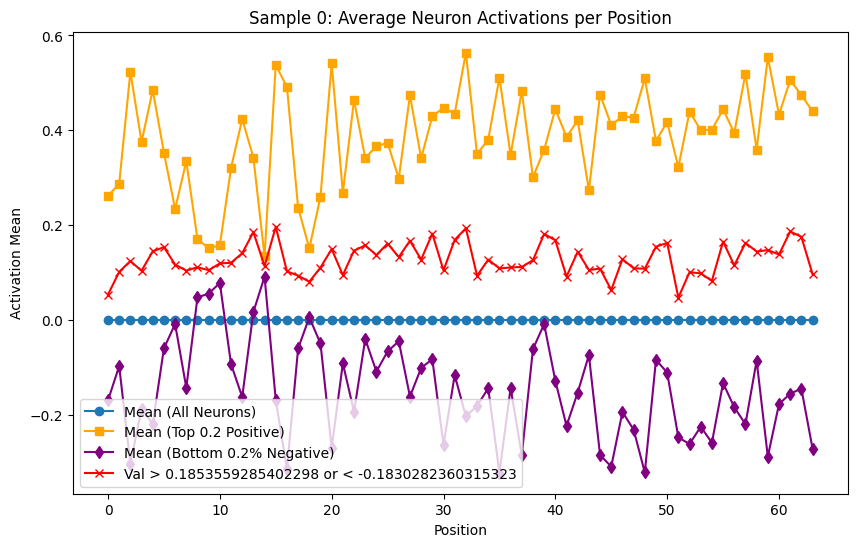

Plotted sample 0


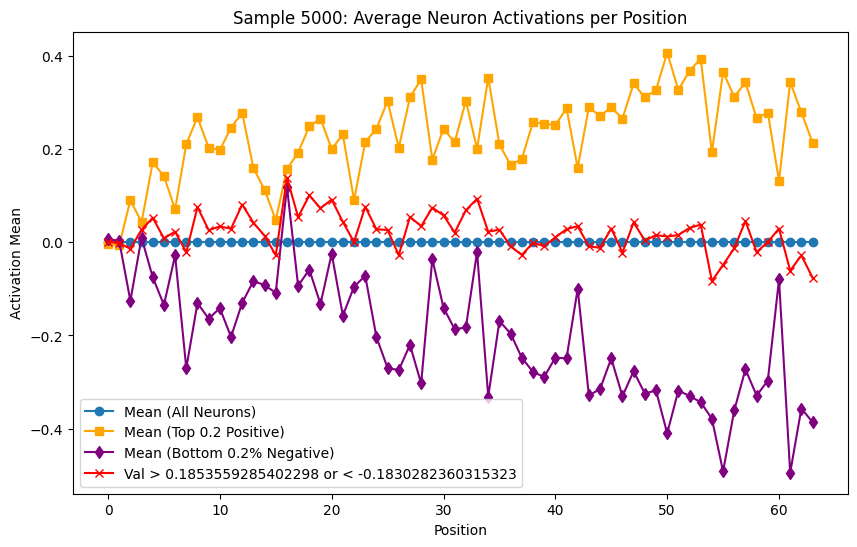

Plotted sample 5000


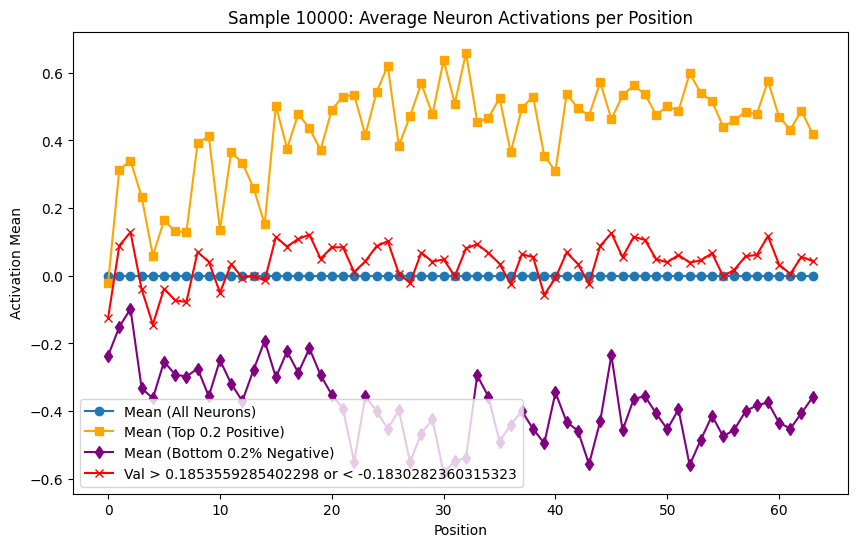

Plotted sample 10000


In [14]:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.2)

# q=0.05

Activations shape: (10240, 64, 1024)
0.27163940817117693 -0.2691446915268898


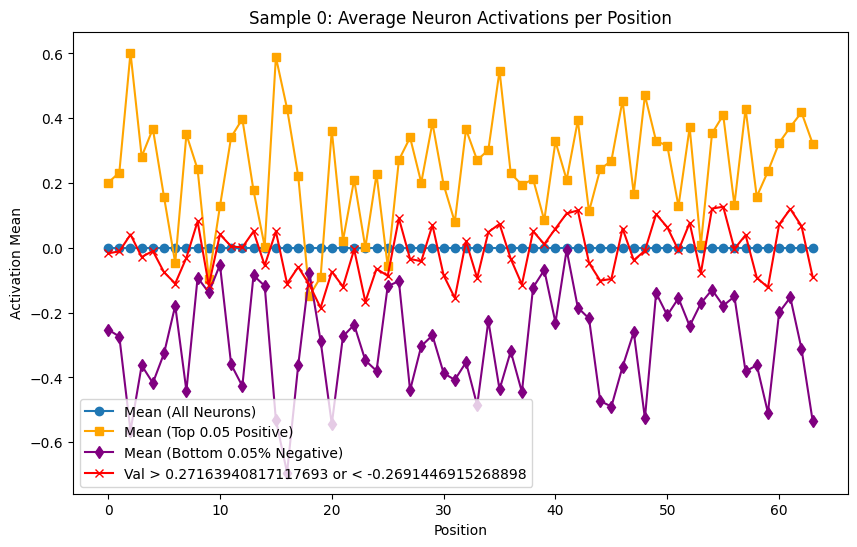

Plotted sample 0


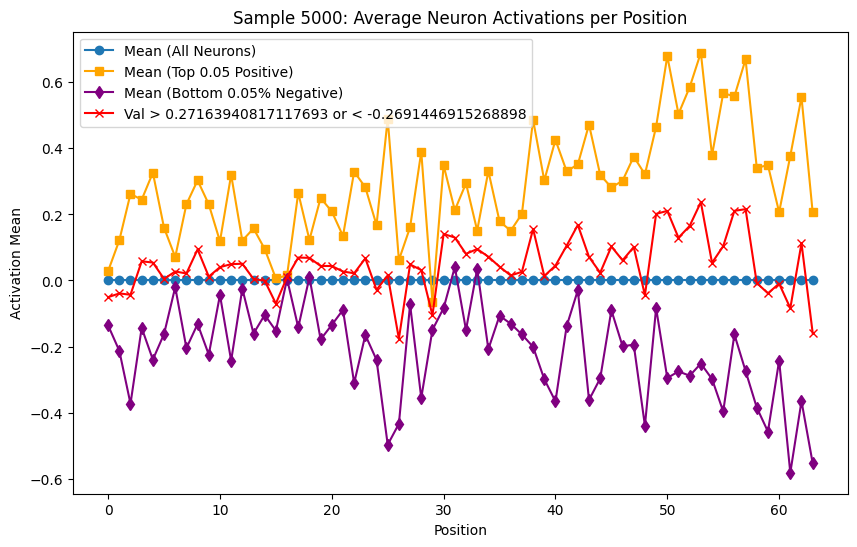

Plotted sample 5000


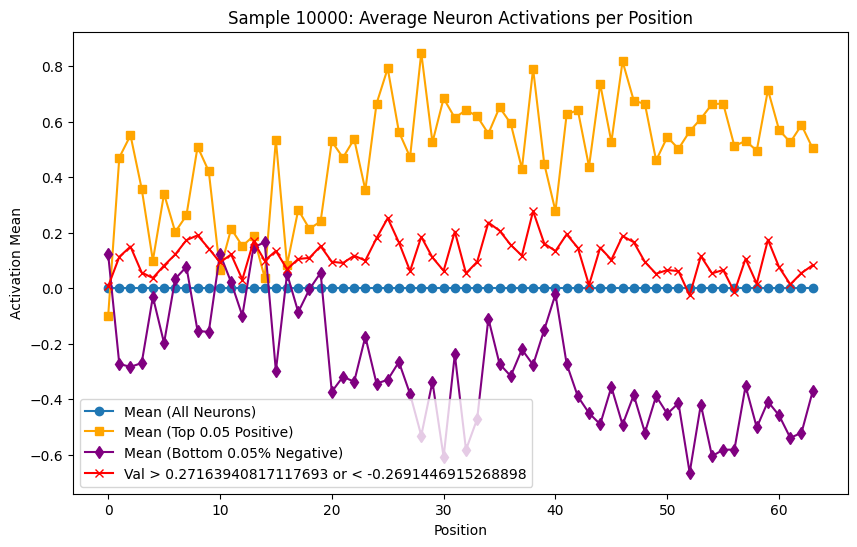

Plotted sample 10000


In [15]:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.05)

# q=0.3

Activations shape: (10240, 64, 1024)
0.34251857757568366 -0.3739475131034851


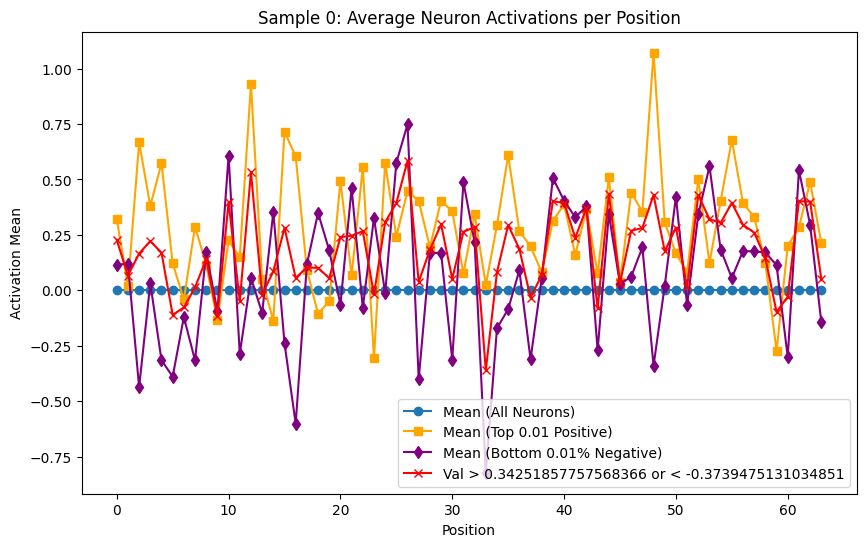

Plotted sample 0


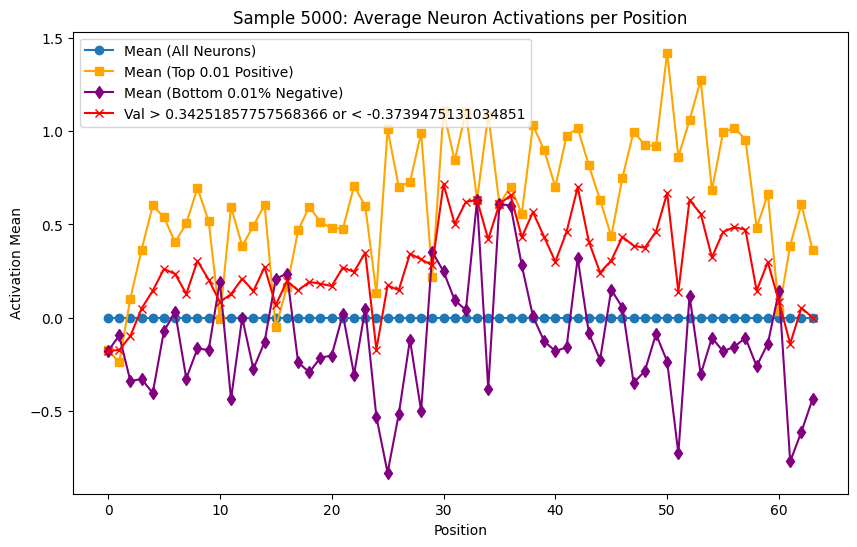

Plotted sample 5000


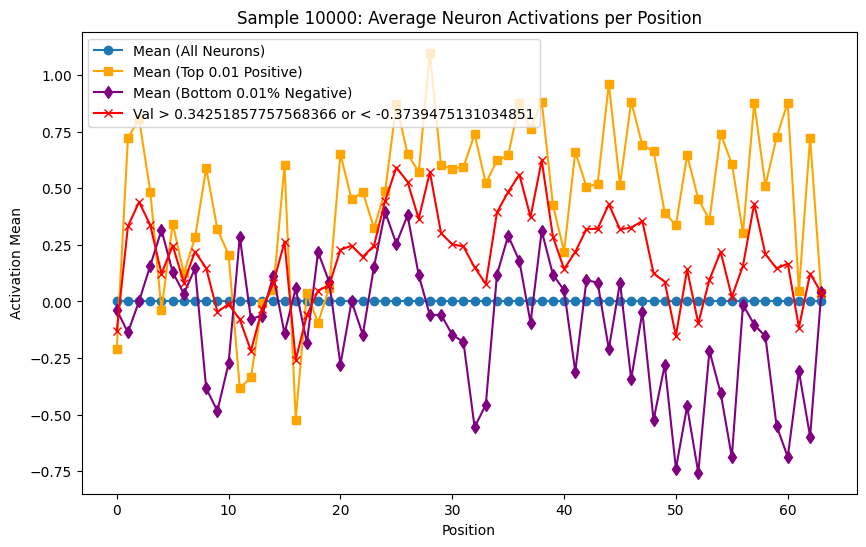

Plotted sample 10000


In [16]:
plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.01)

# Save to disk!

## At the sample level

Activations shape: (10240, 64, 1024)
0.19726192057132722 -0.22187772989273066


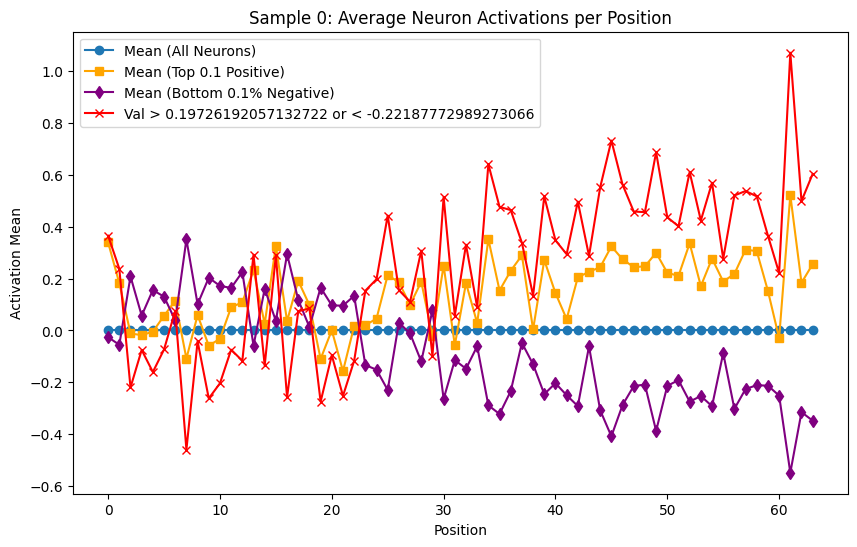

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1, save_to_disk=False, output_dir="plots"):
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    neurons_mean_val = X.mean(axis=0) 
    positive_neurons = neurons_mean_val[neurons_mean_val > 0]
    negative_neurons = neurons_mean_val[neurons_mean_val < 0]
    top_10_percent = np.quantile(positive_neurons, 1 - q)  # Returns a scalar
    bottom_10_percent = np.quantile(negative_neurons, q)
    print(top_10_percent, bottom_10_percent)
    avg_top10_neurons_mask = neurons_mean_val > top_10_percent
    avg_bottom10_neurons_mask = neurons_mean_val < bottom_10_percent

    # Create output directory if saving plots
    if save_to_disk and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # For each sample, compute per-position averages
    for i in range(num_samples):
        sample = activations[i]  # shape: (n_positions, n_neurons)
        positions = np.arange(n_positions)
    
        avg_all = []          # Mean over all neurons.
        avg_top_q_pos = []    # Mean over top 10% positive neurons.
        avg_bottom_q_neg = [] # Mean over bottom 10% negative neurons.
        avg_abs_in_q = []

        for pos_vec in sample:
            position_top10neurons_avg = pos_vec[avg_top10_neurons_mask].mean()
            position_bottom10neurons_avg = pos_vec[avg_bottom10_neurons_mask].mean()
            abs_in_q = pos_vec[avg_top10_neurons_mask].mean() - pos_vec[avg_bottom10_neurons_mask].mean()

            avg_all.append(pos_vec.mean())
            avg_top_q_pos.append(position_top10neurons_avg)
            avg_bottom_q_neg.append(position_bottom10neurons_avg)
            avg_abs_in_q.append(abs_in_q)

        avg_all = np.array(avg_all)
        avg_top_q_pos = np.array(avg_top_q_pos)
        avg_bottom_q_neg = np.array(avg_bottom_q_neg)
        avg_abs_in_q = np.array(avg_abs_in_q)
    
        if i == 0:
            plt.figure(figsize=(10, 6))
            plt.plot(positions, avg_all, marker='o', label='Mean (All Neurons)')
            plt.plot(positions, avg_top_q_pos, marker='s', label=f'Mean (Top {q} Positive)', color='orange')
            plt.plot(positions, avg_bottom_q_neg, marker='d', label=f'Mean (Bottom {q}% Negative)', color='purple')
            plt.plot(positions, avg_abs_in_q, marker='x', label=f'Val > {top_10_percent} or < {bottom_10_percent}', color='red')
            plt.xlabel('Position')
            plt.ylabel('Activation Mean')
            plt.title(f'Sample {i}: Average Neuron Activations per Position')
            plt.legend()

            if save_to_disk:
                # Save the plot to disk
                plot_path = os.path.join(output_dir, f"sample_{i}_q={q}_plot.png")
                plt.savefig(plot_path)
                print(f"Plot saved to {plot_path}")
            else:
                # Show the plot
                plt.show()

            plt.close()

# Example call:
# plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1, save_to_disk=False, output_dir="./activation_plots")

In [ ]:
# for i in [0.01,0.03,0.05,0.08,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]:
    # plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=i,  save_to_disk=True)
    # print(i)
    # print("Done")

Activations shape: (10240, 64, 1024)
0.34600544035434727 -0.3554338836669922
Plot saved to plots/sample_0_q=0.01_plot.png
0.01
Done
Activations shape: (10240, 64, 1024)
0.2677206134796142 -0.29318401098251345
Plot saved to plots/sample_0_q=0.03_plot.png
0.03
Done
Activations shape: (10240, 64, 1024)
0.23582192212343203 -0.2642871081829071
Plot saved to plots/sample_0_q=0.05_plot.png
0.05
Done
Activations shape: (10240, 64, 1024)
0.21130356132984163 -0.24307369887828828
Plot saved to plots/sample_0_q=0.08_plot.png
0.08
Done
Activations shape: (10240, 64, 1024)
0.19726192057132722 -0.22187772989273066
Plot saved to plots/sample_0_q=0.1_plot.png


0.1
Done
Activations shape: (10240, 64, 1024)
0.17784169018268586 -0.19305096864700316
Plot saved to plots/sample_0_q=0.15_plot.png
0.15
Done
Activations shape: (10240, 64, 1024)
0.16163020133972172 -0.1734447658061981
Plot saved to plots/sample_0_q=0.2_plot.png
0.2
Done
Activations shape: (10240, 64, 1024)
0.1522047221660614 -0.1517307311296463
Plot saved to plots/sample_0_q=0.25_plot.png
0.25
Done
Activations shape: (10240, 64, 1024)
0.1367098957300186 -0.13300484120845796
Plot saved to plots/sample_0_q=0.3_plot.png
0.3
Done
Activations shape: (10240, 64, 1024)
0.12429009824991226 -0.12249705493450165
Plot saved to plots/sample_0_q=0.35_plot.png
0.35
Done
Activations shape: (10240, 64, 1024)
0.10740610659122468 -0.11116572171449661
Plot saved to plots/sample_0_q=0.4_plot.png
0.4
Done
Activations shape: (10240, 64, 1024)
0.10047548711299896 -0.09941540658473969
Plot saved to plots/sample_0_q=0.45_plot.png
0.45
Done
Activations shape: (10240, 64, 1024)
0.0895031988620758 -0.08637145906

# Train linear regressor

In [125]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

SAMPLE = None

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1, save_to_disk=False, output_dir="./plots_neurons"):
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    neurons_mean_val = X.mean(axis=0) 

    # Identify positive and negative neurons based on quantiles
    positive_neurons = neurons_mean_val[neurons_mean_val > 0]
    negative_neurons = neurons_mean_val[neurons_mean_val < 0]

    top_positive_threshold = np.quantile(positive_neurons, 1 - q)
    bottom_negative_threshold = np.quantile(negative_neurons, q)

    positive_neurons_ids = np.where(neurons_mean_val > top_positive_threshold)[0]
    negative_neurons_ids = np.where(neurons_mean_val < bottom_negative_threshold)[0]

    selected_neurons_ids = np.concatenate([positive_neurons_ids, negative_neurons_ids])

    # Create output directory if saving plots
    if save_to_disk and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Train a linear regressor for each sample
    range_vals = np.arange(1, n_positions + 1).reshape(-1, 1)  # Target line [1, 64]
    regressor = LinearRegression()
    print(f'Selected positive neurons: {len(positive_neurons_ids)}')
    print(f'Selected negative neurons: {len(negative_neurons_ids)}')

    selected_activations = activations[:, :, selected_neurons_ids]
    Y = np.tile(range_vals, (num_samples, 1)).reshape(-1, 1)  # Shape: (num_samples * n_positions, 1)
    regressor.fit(selected_activations.reshape(-1, len(selected_neurons_ids)), Y)
    # Predict the positions using the trained model
    for i in range(num_samples):
        # Extract activations for the selected neurons
        selected_activations = activations[i][:, selected_neurons_ids]
        predicted_positions = regressor.predict(selected_activations)

        # Plot the true positions vs. predicted positions for the first sample
        if i in [0,1,2,3]:
            plt.figure(figsize=(10, 6))
            plt.plot(range_vals, range_vals, label='True Line', color='blue', linestyle='--')
            plt.plot(range_vals, predicted_positions, label='Predicted Line', color='red')
            plt.xlabel('Position')
            plt.ylabel('Predicted Position')
            plt.title(f'Linear Regression Prediction of Positions for sample {i}\n'
                      f'q={q}, Positive Neurons={len(positive_neurons_ids)}, Negative Neurons={len(negative_neurons_ids)}')
            plt.legend()

            if save_to_disk:
                plot_path = os.path.join(output_dir, f"linear_regression_q={q}_plot.png")
                plt.savefig(plot_path)
                print(f"Plot saved to {plot_path}")
            else:
                plt.show()

            plt.close()
    return regressor, selected_neurons_ids
# Example call:
# plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.03, save_to_disk=False, output_dir="activation_plots")

In [ ]:
for i in [0.8, 0.9, 1]:
    regressor, selected_neurons_ids = plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=i,  save_to_disk=False, output_dir="./plots_neurons")
    print(i)
    print("-"*30)

Activations shape: (10240, 64, 2048)


Selected positive neurons: 832
Selected negative neurons: 805


In [49]:
selected_neurons_ids

array([   5,   45,   90,   92,   93,  118,  122,  125,  135,  145,  152,
        165,  173,  211,  232,  250,  277,  283,  299,  375,  416,  505,
        507,  518,  527,  542,  568,  600,  610,  647,  688,  690,  715,
        730,  767,  772,  795,  873,  883,  950,  988, 1009, 1012,   16,
         32,   66,  114,  129,  131,  195,  205,  207,  215,  282,  286,
        349,  370,  432,  433,  445,  448,  499,  541,  604,  653,  680,
        711,  749,  766,  768,  773,  804,  835,  862,  886,  904,  922,
        925,  955,  992,  993,  997, 1016])

In [55]:
sample_id = 222


In [56]:
cache['blocks.0.ln2.hook_normalized'][sample_id].shape

torch.Size([64, 1024])

In [59]:
cache['blocks.0.ln2.hook_normalized'][sample_id][:, selected_neurons_ids].shape

torch.Size([64, 83])

In [64]:
help(np.tile)

Help on _ArrayFunctionDispatcher in module numpy:

tile(A, reps)
    Construct an array by repeating A the number of times given by reps.

    If `reps` has length ``d``, the result will have dimension of
    ``max(d, A.ndim)``.

    If ``A.ndim < d``, `A` is promoted to be d-dimensional by prepending new
    axes. So a shape (3,) array is promoted to (1, 3) for 2-D replication,
    or shape (1, 1, 3) for 3-D replication. If this is not the desired
    behavior, promote `A` to d-dimensions manually before calling this
    function.

    If ``A.ndim > d``, `reps` is promoted to `A`.ndim by pre-pending 1's to it.
    Thus for an `A` of shape (2, 3, 4, 5), a `reps` of (2, 2) is treated as
    (1, 1, 2, 2).

    Note : Although tile may be used for broadcasting, it is strongly
    recommended to use numpy's broadcasting operations and functions.

    Parameters
    ----------
    A : array_like
        The input array.
    reps : array_like
        The number of repetitions of `A` along ea

In [66]:
regressor.coef_.shape

(1, 83)

In [85]:
regressor.intercept_

array([18.864616], dtype=float32)

In [68]:
np.tile(regressor.coef_, reps=(64,1)).shape

(64, 83)

In [74]:
line((torch.tensor(np.tile(regressor.coef_, reps=(64,1))) * cache['blocks.0.ln2.hook_normalized'][sample_id][:, selected_neurons_ids]).mean(axis=1))

In [76]:
(torch.tensor(np.tile(regressor.coef_, reps=(64,1))) * cache['blocks.0.ln2.hook_normalized'][sample_id][:, selected_neurons_ids]).sum(axis=1)

tensor([ 26.8013,  19.0970,   8.2466,  13.4935,   1.1119,  13.7542,  13.9586,
          5.0541,  12.3059,  22.4345,   8.4259,  -4.6415, -18.2397,  -8.0273,
         -9.6509,   2.0659,  15.1232,  10.8921,  18.7309,  10.8182,  13.0759,
          5.5028,  -5.5854,   6.6841,   6.0293,  -3.0450,  19.1039,  20.0106,
         48.2628,  16.4451,  23.7311,   0.3081,  20.6099,  20.7149,  17.3298,
          7.3382,  19.4414,  24.6544,   9.4454,  28.7973,   5.3818,  32.8040,
          5.0806, -15.6148, -18.8498,  10.4716,  39.0402,  11.2440,  10.2907,
         22.7370,  42.7376,   3.0532,  35.6668,  10.7141,  27.8160,   3.6915,
         10.8460,  19.5634,  21.5400,  20.6191,  32.2411,  23.6386,   4.5526,
          2.6928])

In [81]:
line((torch.tensor(np.tile(regressor.coef_, reps=(64,1))) @ cache['blocks.0.ln2.hook_normalized'][sample_id][:, selected_neurons_ids].T).mean(1))

In [ ]:
regressor.

AttributeError: 'LinearRegression' object has no attribute 'feature_names_in_'

In [ ]:
## Works only for 0 :(

In [97]:
(torch.tensor(np.tile(regressor.coef_, reps=(64,1))) * cache['blocks.0.ln2.hook_normalized'][0][:, selected_neurons_ids]).sum(axis=1) + regressor.intercept_

tensor([ 1.0000,  2.0000,  3.0000,  4.0000,  5.0000,  6.0000,  7.0000,  8.0000,
         9.0000, 10.0000, 11.0000, 12.0000, 13.0000, 14.0000, 15.0000, 16.0000,
        17.0000, 18.0000, 19.0000, 20.0000, 21.0000, 22.0000, 23.0000, 24.0000,
        25.0000, 26.0000, 27.0000, 28.0000, 29.0000, 30.0000, 31.0000, 32.0000,
        33.0000, 34.0000, 35.0000, 36.0000, 37.0000, 38.0000, 39.0000, 40.0000,
        41.0000, 42.0000, 43.0000, 44.0000, 45.0000, 46.0000, 47.0000, 48.0000,
        49.0000, 50.0000, 51.0000, 52.0000, 53.0000, 54.0000, 55.0000, 56.0000,
        57.0000, 58.0000, 59.0000, 60.0000, 61.0000, 62.0000, 63.0000, 64.0000])

In [82]:
line(torch.tensor(np.tile(regressor.coef_, reps=(64,1))) * cache['blocks.0.ln2.hook_normalized'][12][:, selected_neurons_ids])

In [69]:
torch.tensor(np.tile(regressor.coef_, reps=(64,1))) * cache['blocks.0.ln2.hook_normalized'][sample_id][:, selected_neurons_ids]

tensor([[-0.0103, -6.1709, -2.0849,  ..., -1.2523,  3.5959, -3.5501],
        [-0.0829, -5.0070, -1.9207,  ...,  0.0864, -0.4552, -3.0701],
        [-0.1278, -3.3690, -2.0323,  ...,  0.7977, -4.0834, -1.7091],
        ...,
        [ 0.0785,  3.4632, -0.4816,  ...,  1.9059, -7.4971,  1.4612],
        [ 0.3594, -2.1305, -0.6916,  ..., -0.7878, -2.1643,  0.7262],
        [ 0.2848, -0.6926, -1.0213,  ...,  1.3330, -3.3937,  1.7404]])

In [ ]:
regressor.coef_

array([[ 0.1995368 ,  3.010483  , -1.1235447 , -2.8436022 ,  2.4955962 ,
         1.3584244 ,  1.0848198 ,  0.10783911,  3.1359847 ,  0.65847576,
        -0.36898446, -5.64222   ,  2.0167413 , -0.49071068, -2.957013  ,
        -0.8246397 ,  1.0113182 , -1.3896525 , -7.0520887 ,  5.8948445 ,
         2.787313  ,  0.48468077,  0.5580069 ,  4.0630245 , -1.3011657 ,
         3.2591054 ,  1.155571  ,  3.4331734 , -2.8097904 , -0.75747526,
        -2.1740627 ,  0.710377  ,  4.205372  ,  1.292602  ,  3.0323963 ,
        -1.2667458 ,  3.6444936 ,  2.063509  ,  2.7224896 ,  1.3866742 ,
         0.14432251, -3.2870405 ,  3.116816  ,  6.3098493 , -3.499674  ,
        -0.39573935,  0.9905695 ,  0.5748002 , -2.0666697 ,  0.9540079 ,
        -0.6702086 ,  1.2030033 ,  2.4096646 ,  1.5523279 ,  0.17943369,
        -1.0860202 ,  1.3028013 , -0.05250812,  0.8529061 ,  2.3161016 ,
        -5.405576  ,  1.8702899 , -0.57115024,  1.4683939 ,  0.33914027,
        -0.3728366 , -0.6255183 ,  1.0525663 , -2.9

Activations shape: (10240, 64, 1024)
Selected positive neurons: 6
Selected negative neurons: 5


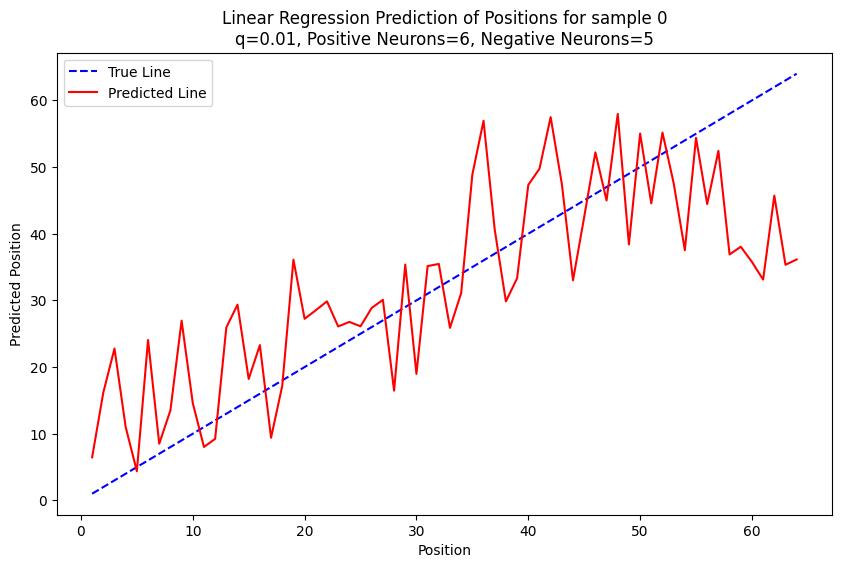

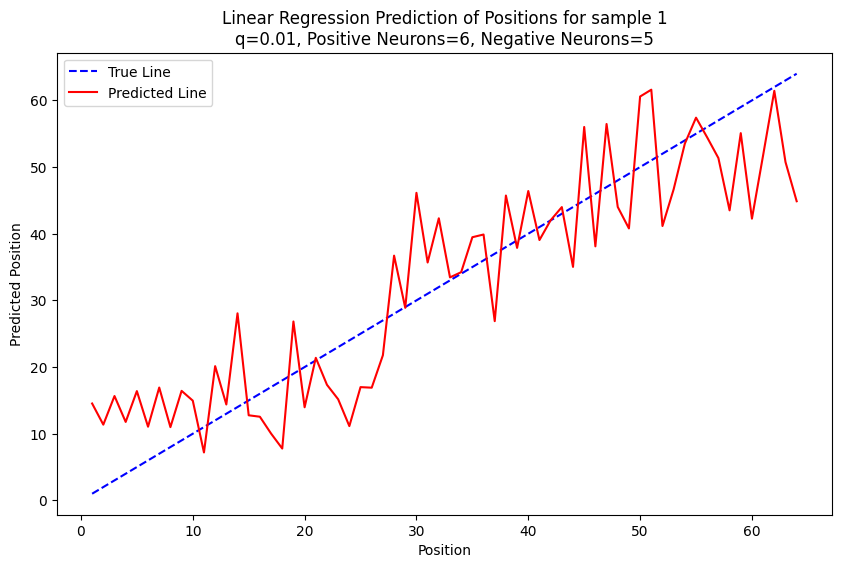

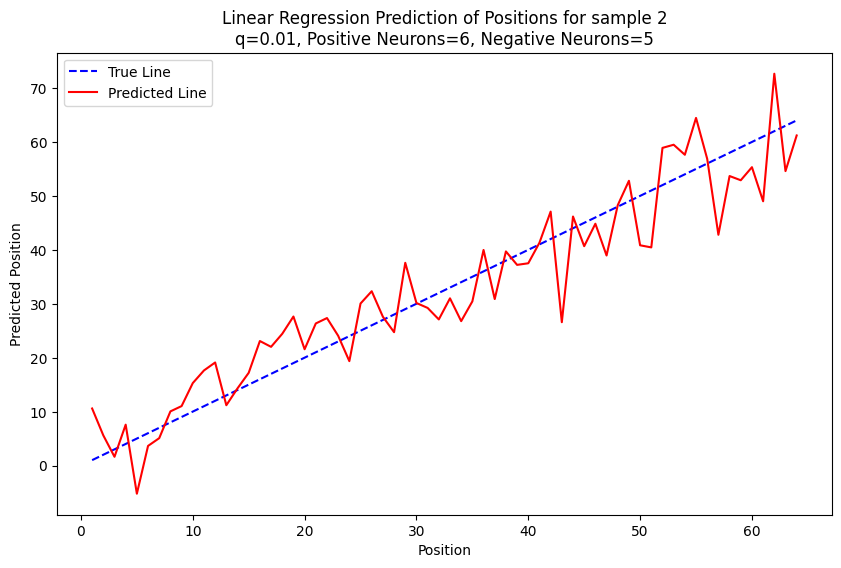

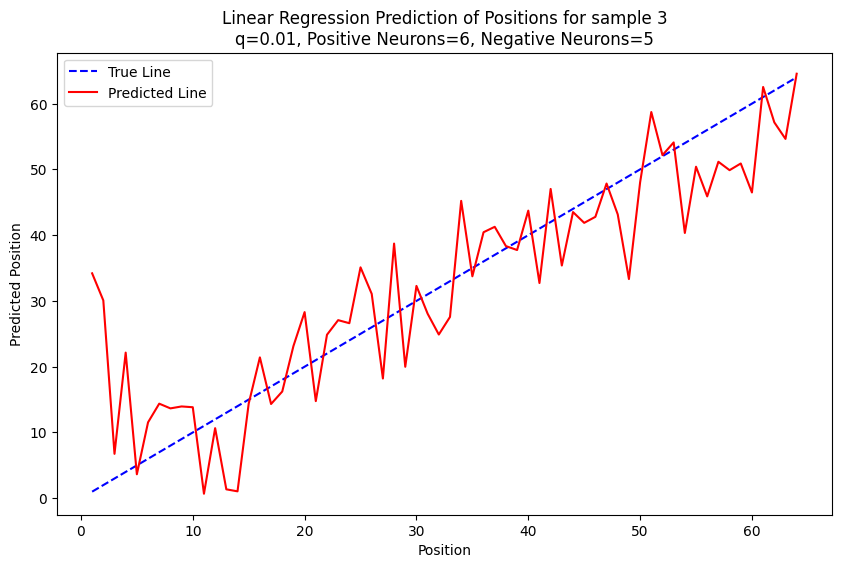

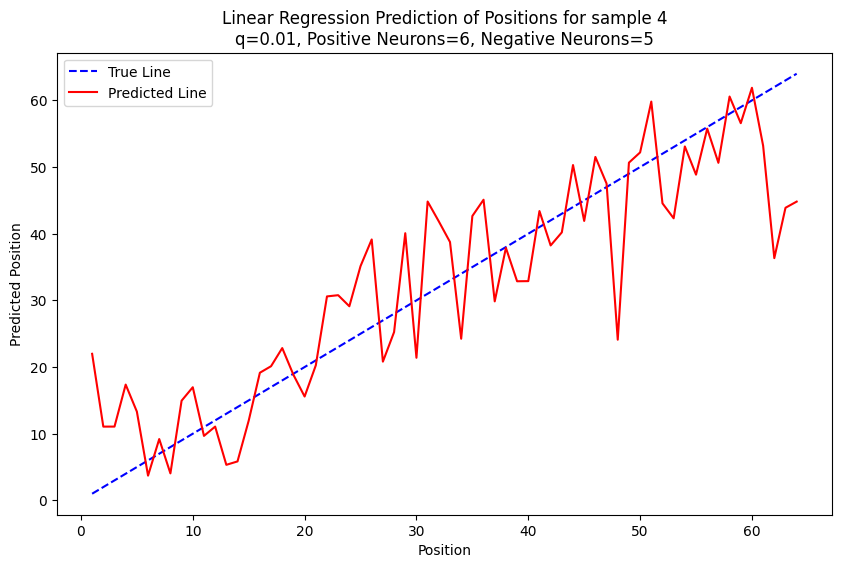

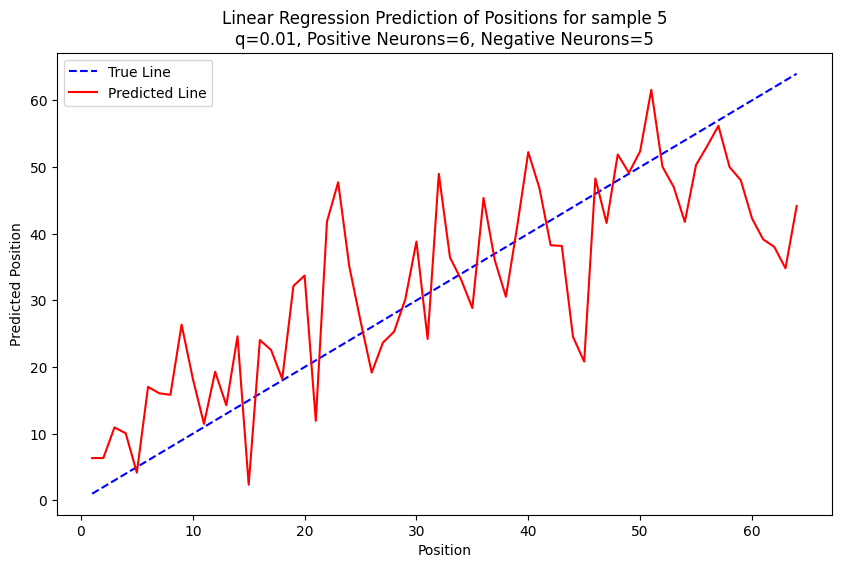

0.01
------------------------------
Activations shape: (10240, 64, 1024)
Selected positive neurons: 16
Selected negative neurons: 15


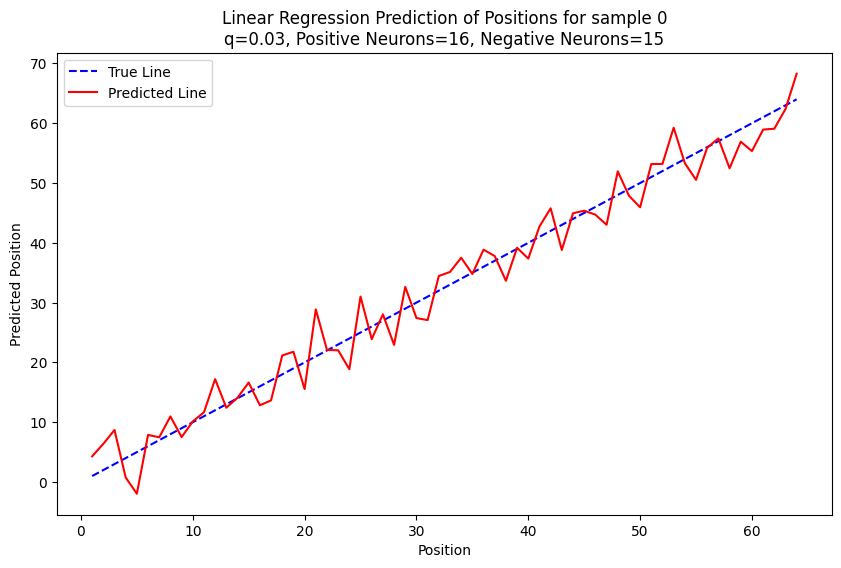

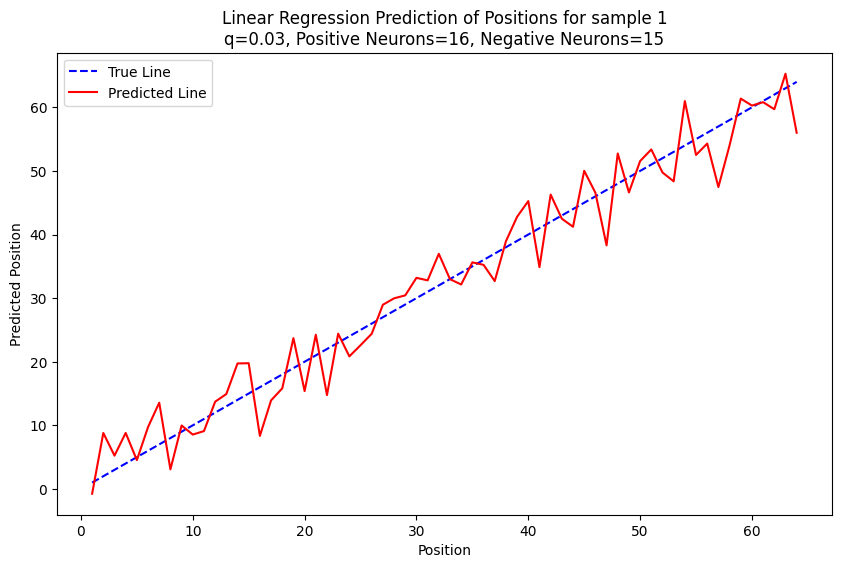

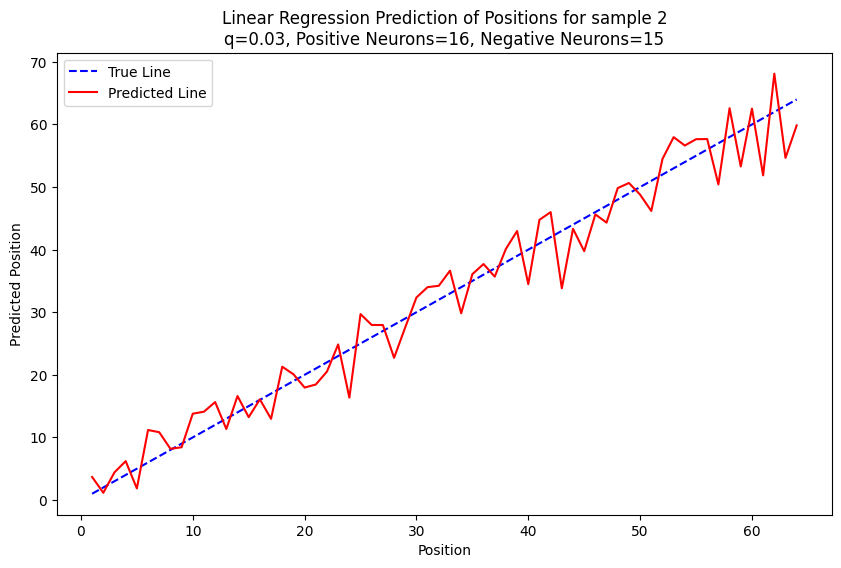

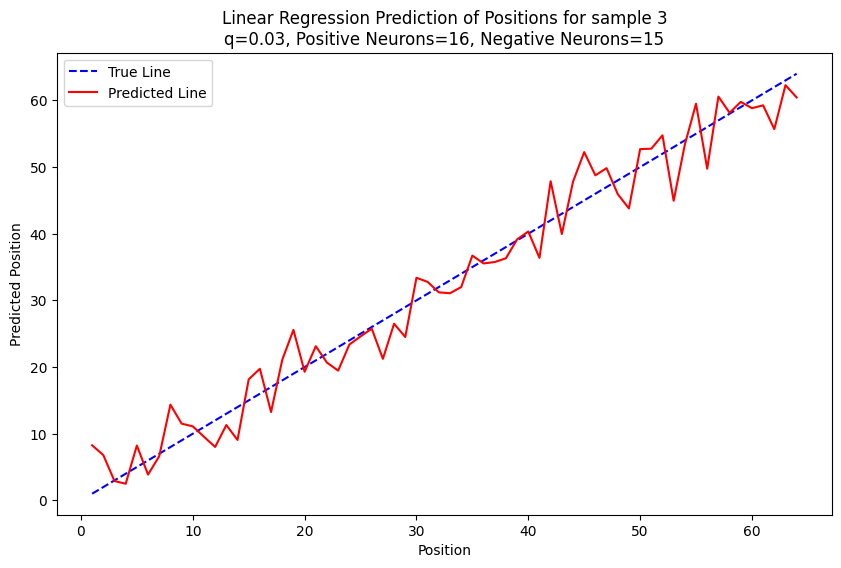

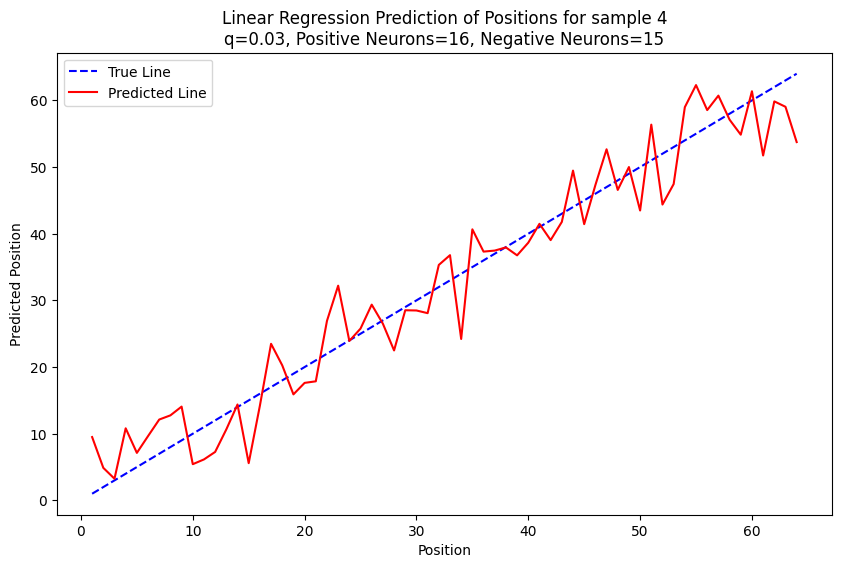

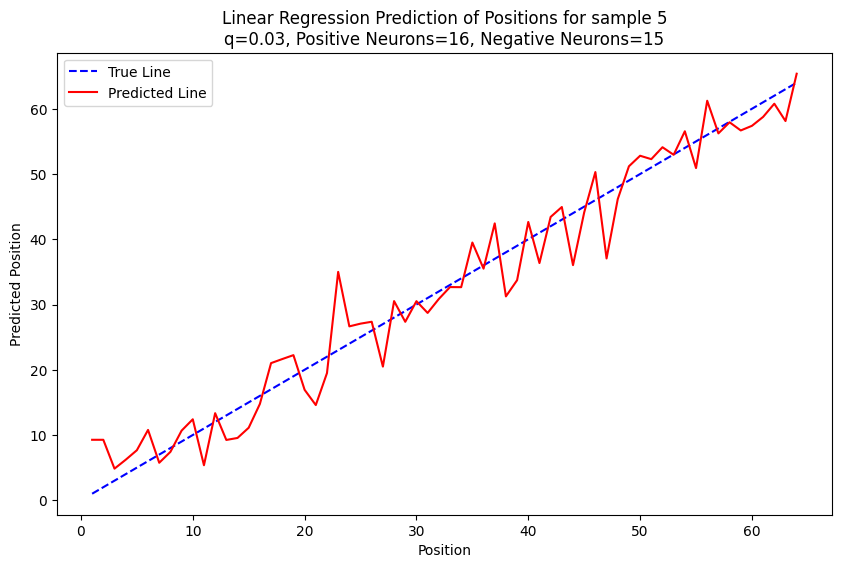

0.03
------------------------------
Activations shape: (10240, 64, 1024)
Selected positive neurons: 27
Selected negative neurons: 25


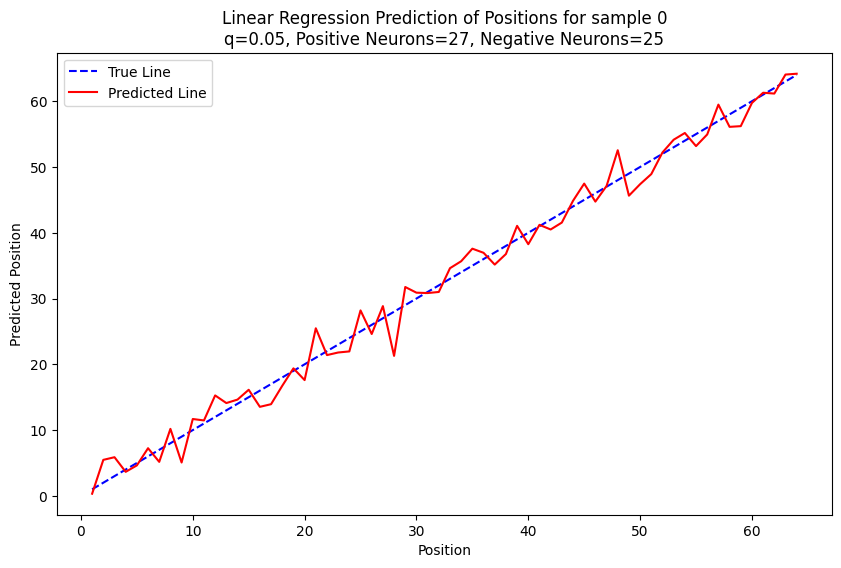

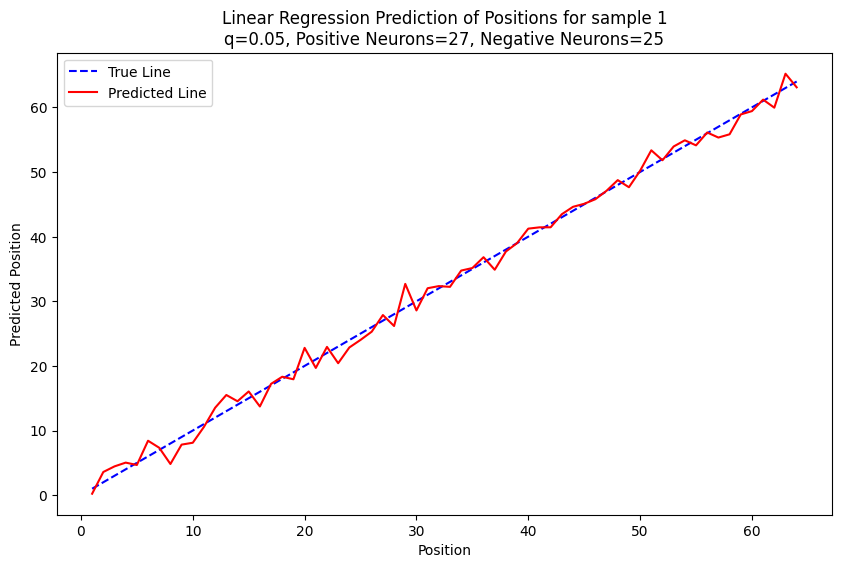

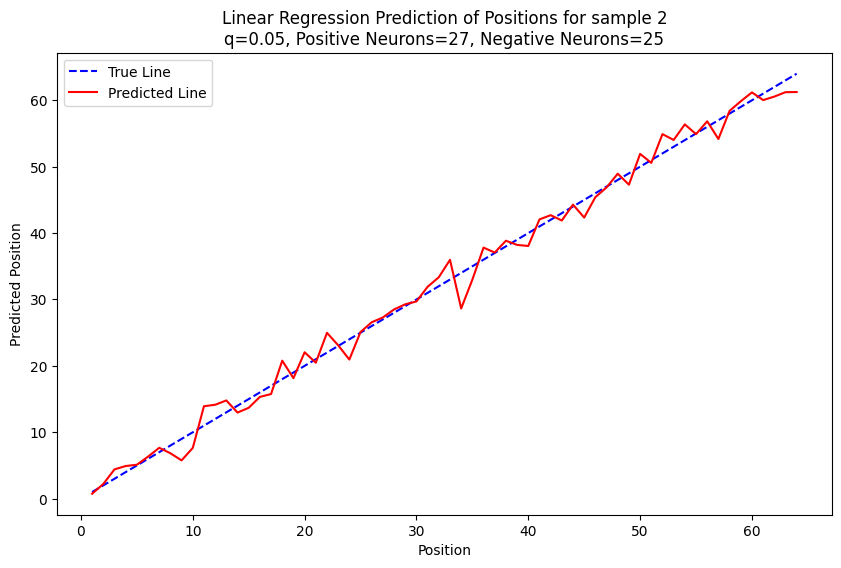

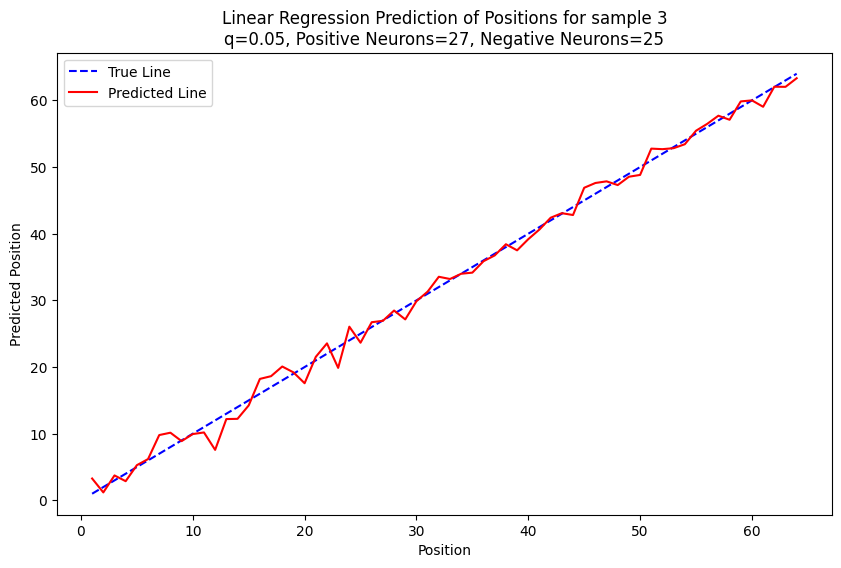

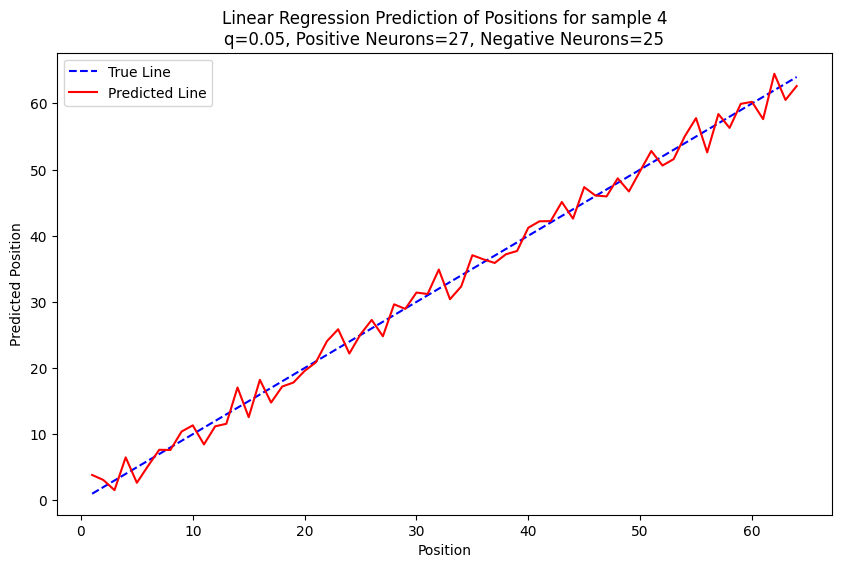

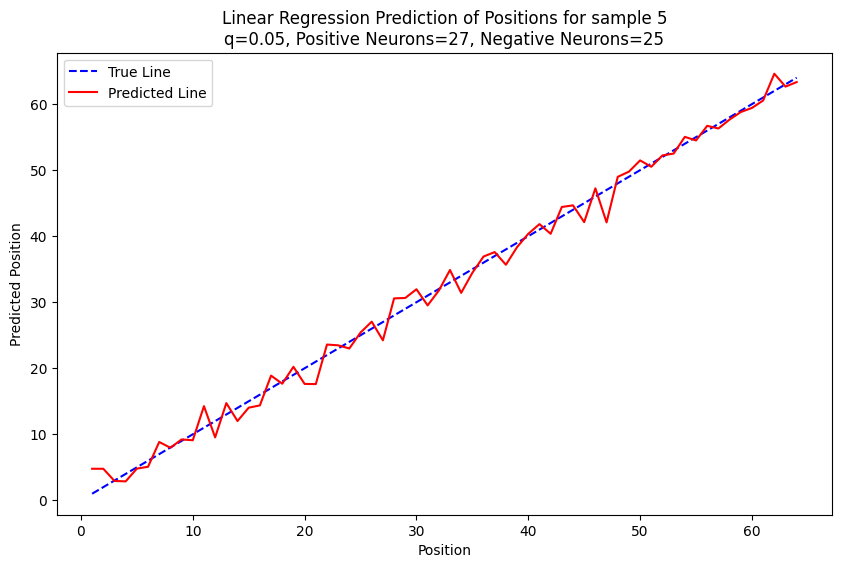

0.05
------------------------------
Activations shape: (10240, 64, 1024)
Selected positive neurons: 43
Selected negative neurons: 40


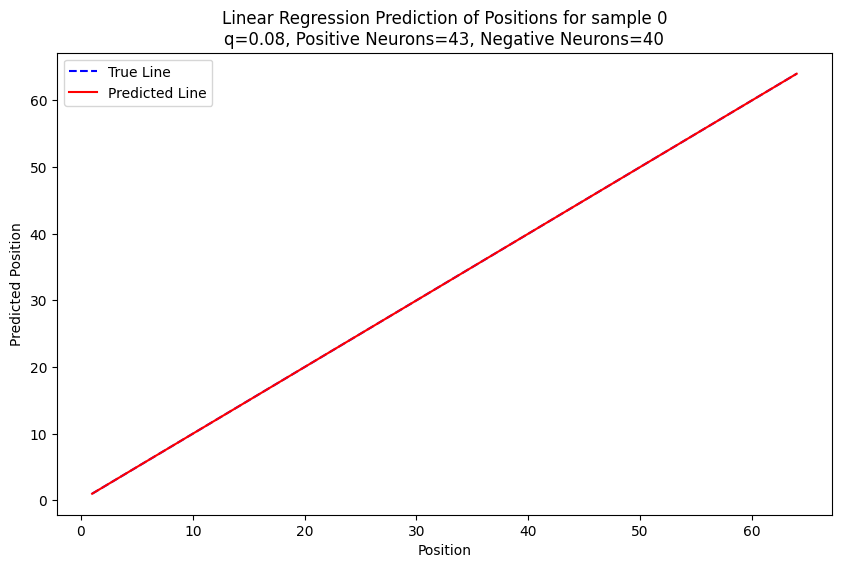

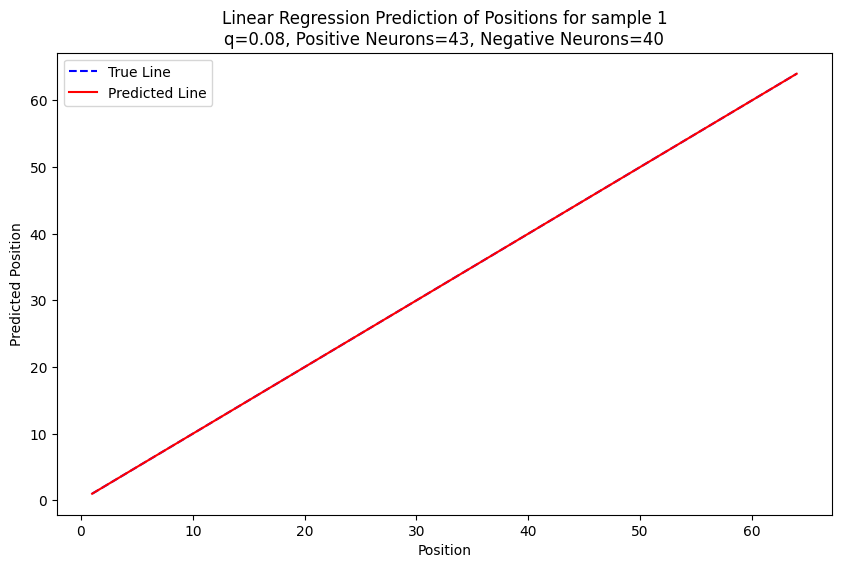

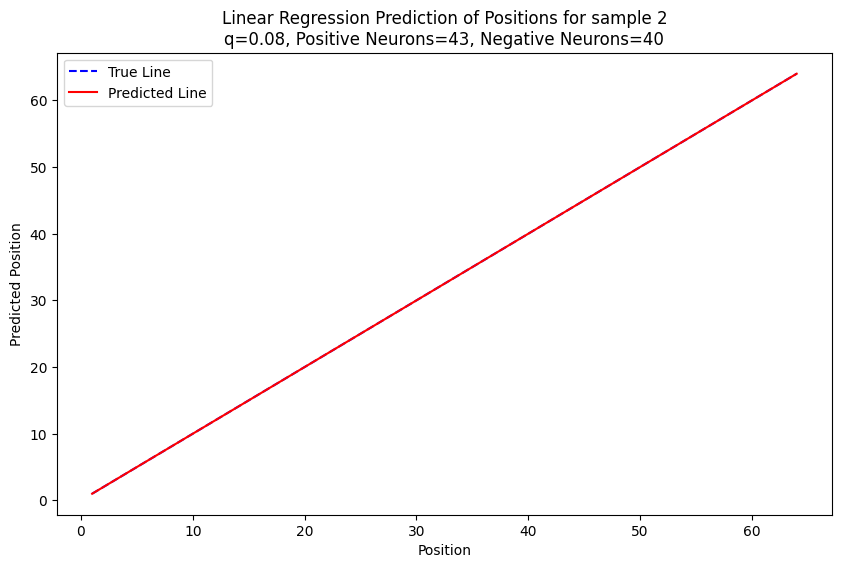

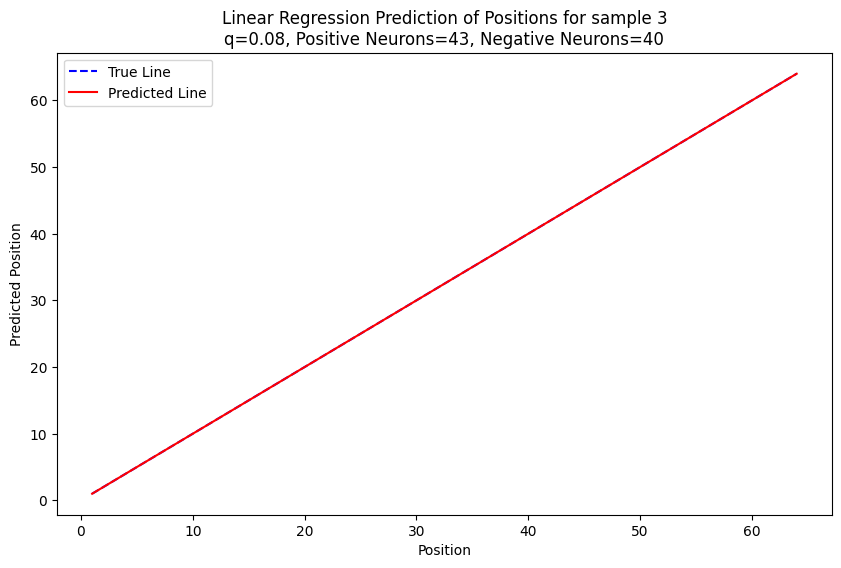

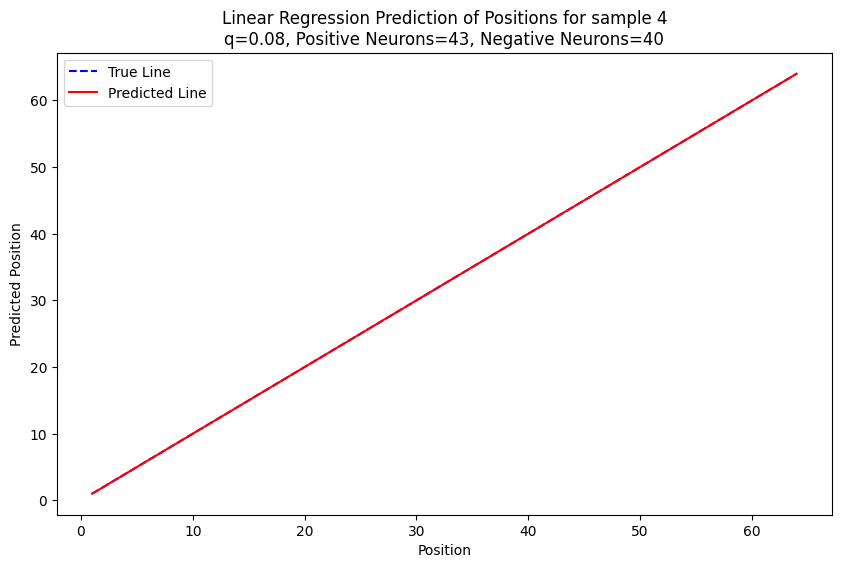

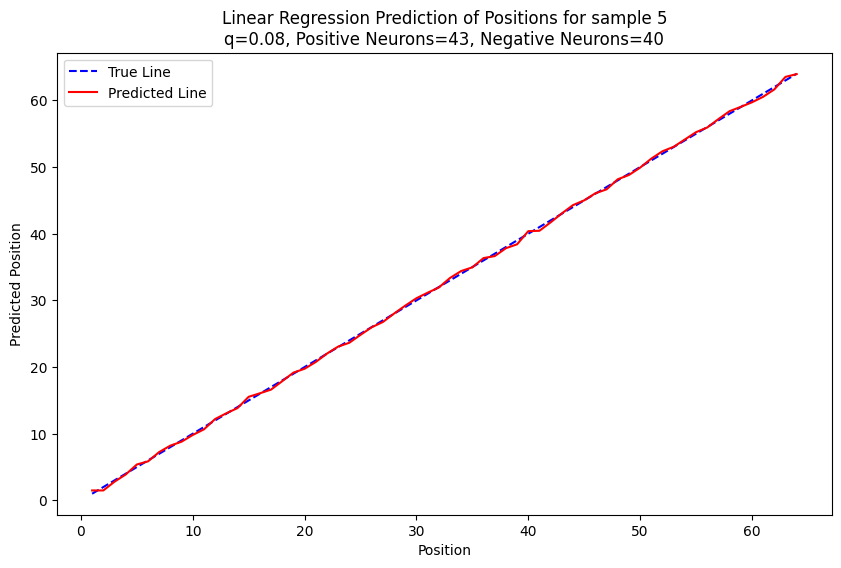

0.08
------------------------------
Activations shape: (10240, 64, 1024)
Selected positive neurons: 53
Selected negative neurons: 50


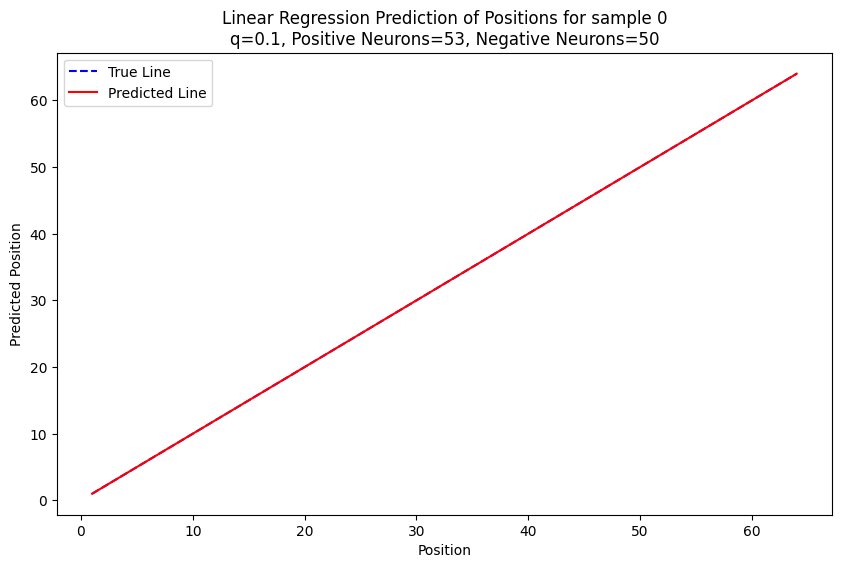

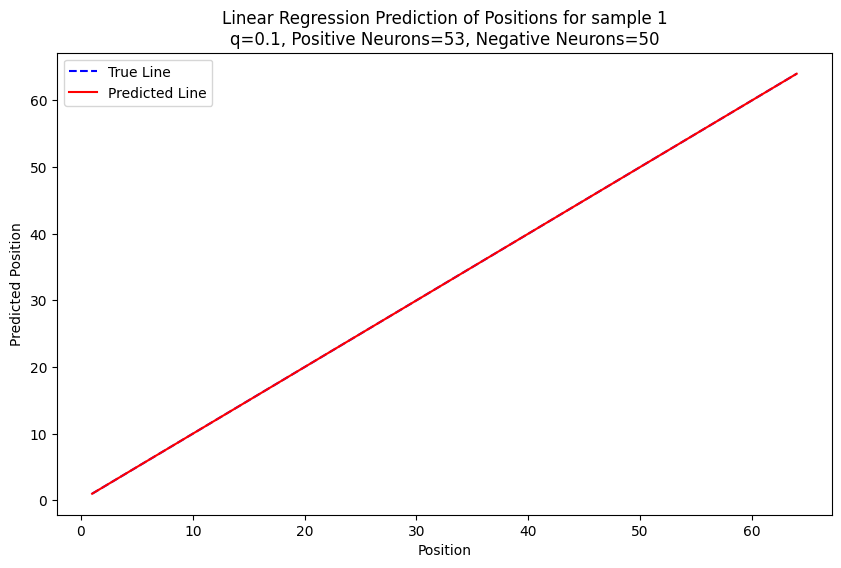

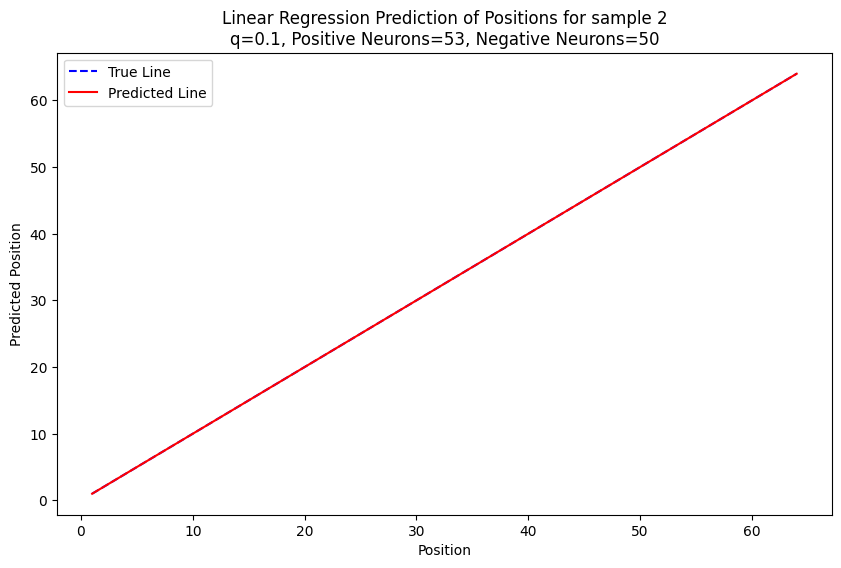

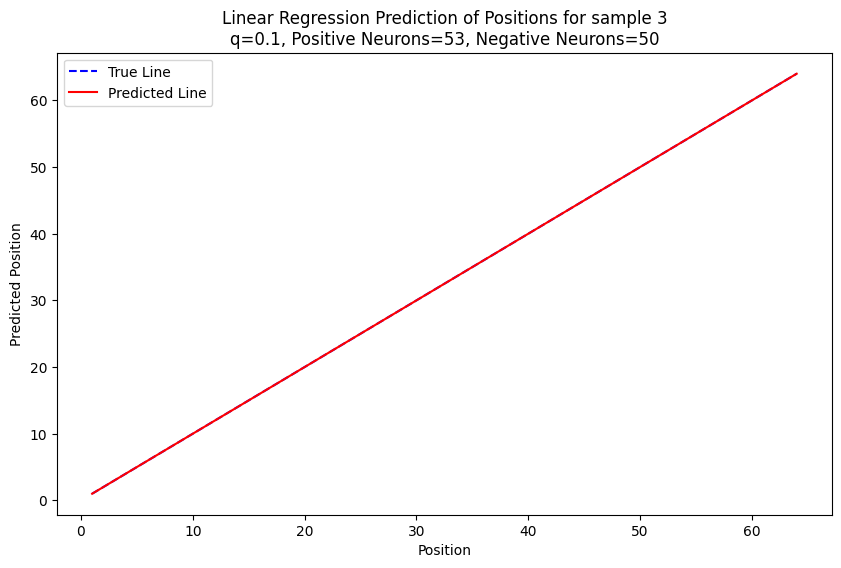

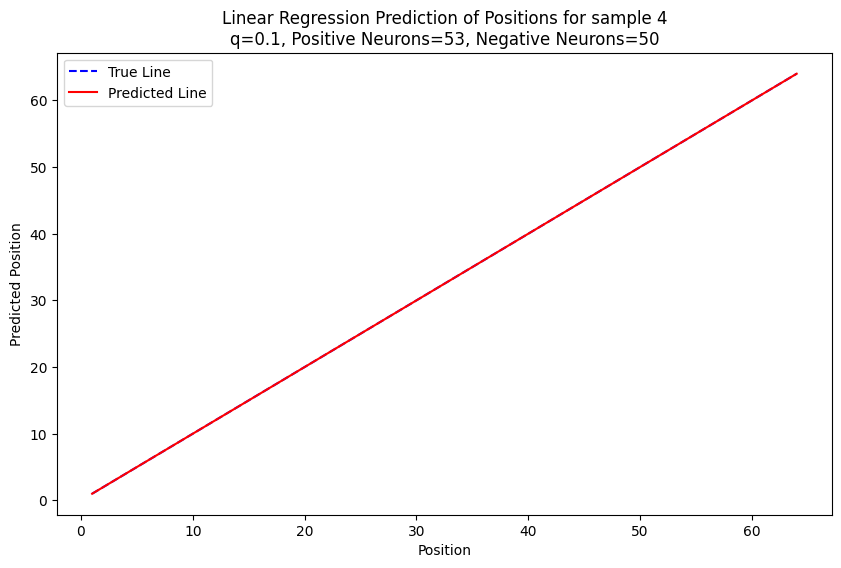

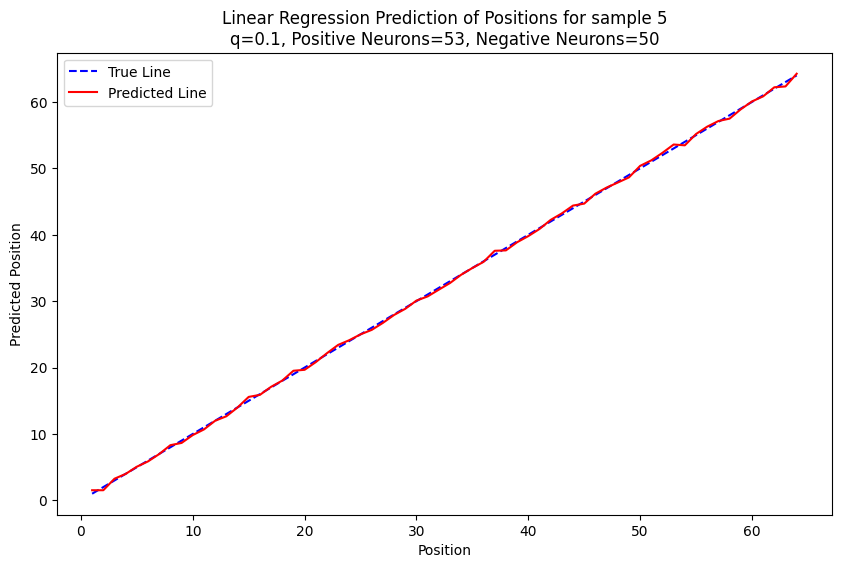

0.1
------------------------------
Activations shape: (10240, 64, 1024)
Selected positive neurons: 80
Selected negative neurons: 75


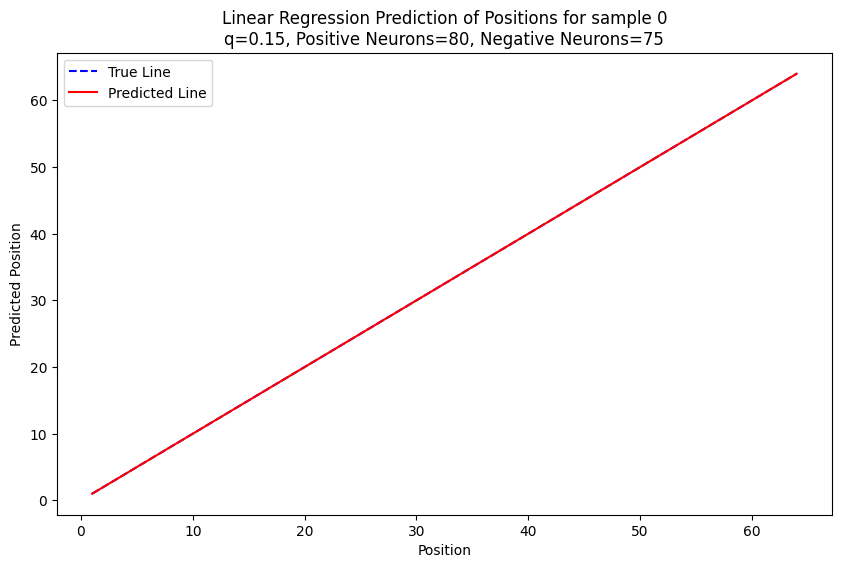

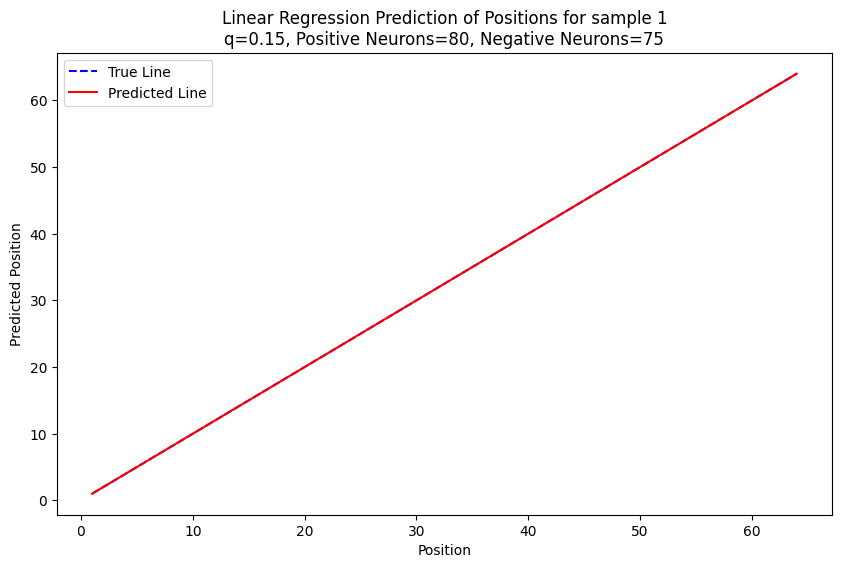

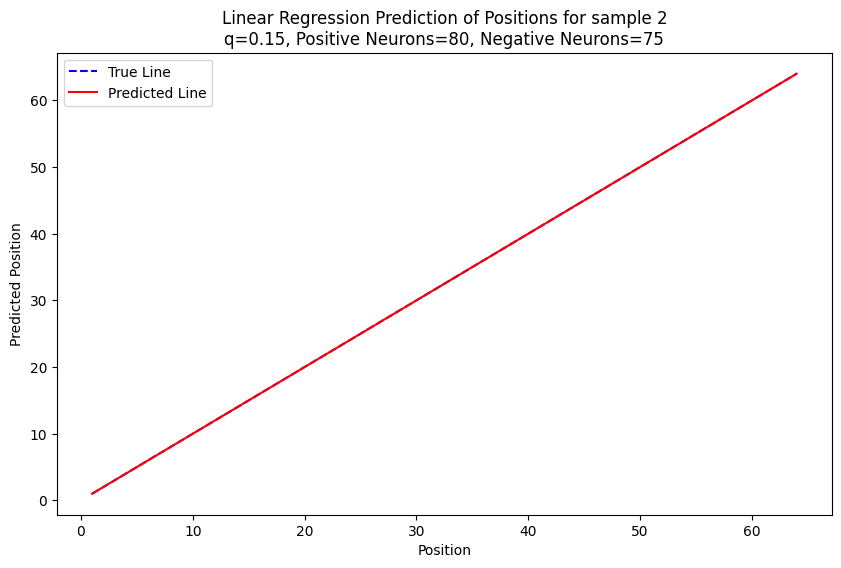

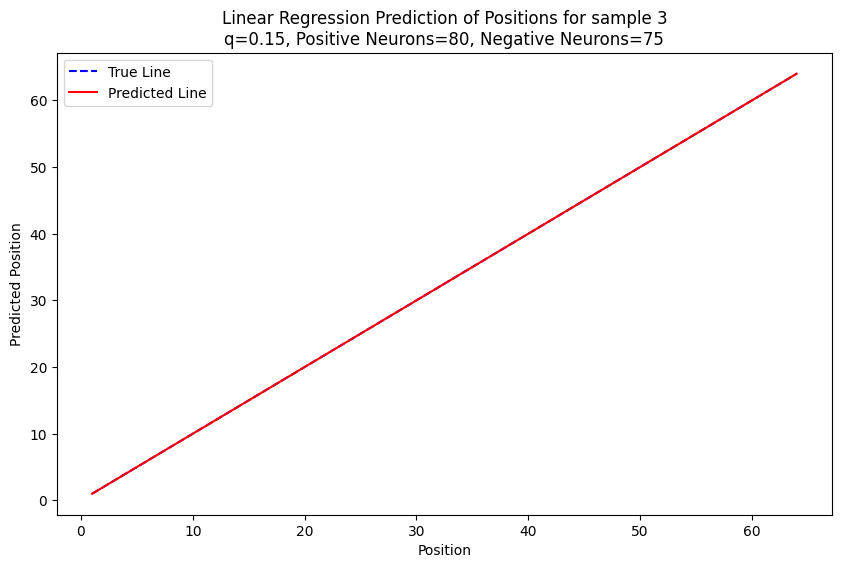

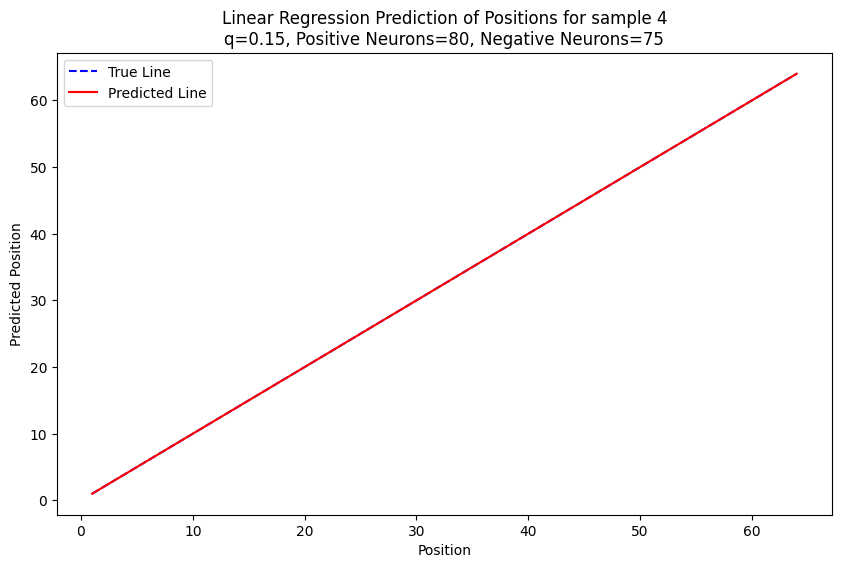

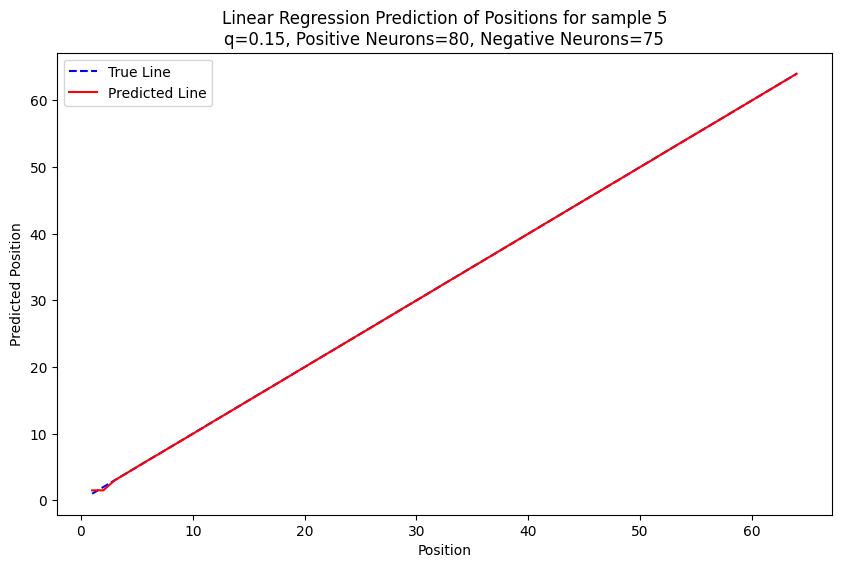

KeyboardInterrupt: 

In [ ]:
for i in [0.01,0.03,0.05,0.08,0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    regressor = plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=i,  save_to_disk=False, output_dir="./plots_neurons")
    print(i)
    print("-"*30)

# Find best subgroup

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from itertools import combinations
from tqdm import tqdm

SAMPLE = None

# ---------------- Improved Activation Statistics Plotting ----------------
def plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.1, save_to_disk=False, output_dir="./plots_neurons"):
    # Get activations with shape: (batch, ctx, neurons)
    activations = cache[act]
    # activations = activations[range(SAMPLE)]
    activations = activations.cpu().numpy()

    num_samples, n_positions, n_neurons = activations.shape
    print("Activations shape:", activations.shape)
    
    # Flatten (batch, ctx) to get X, and compute thresholds using the given quantiles.
    X = activations.reshape(-1, n_neurons)
    neurons_mean_val = X.mean(axis=0) 
    positive_neurons = neurons_mean_val[neurons_mean_val > 0]
    top_10_percent = np.quantile(positive_neurons, 1 - q)  # Returns a scalar
    avg_top10_neurons_mask = neurons_mean_val > top_10_percent
    avg_top10_neurons_ids = np.where(avg_top10_neurons_mask)[0] 

    # Create output directory if saving plots
    if save_to_disk and not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Initialize variables to track correlations
    subgroup_correlations = {}  # Dictionary to store correlations for each subgroup

    # Iterate over all subgroup sizes
    for r in tqdm(range(1, len(avg_top10_neurons_ids) + 1)):
        if r > 3 and r < len(avg_top10_neurons_ids) - 2:
            continue
        for subgroup in tqdm(combinations(avg_top10_neurons_ids, r)):  # Generate all combinations of size `r`
            subgroup = tuple(subgroup)  # Convert to tuple to use as a dictionary key
            subgroup_correlations[subgroup] = []  # Initialize list to store correlations for this subgroup

            # Calculate correlation for each sample
            for i in range(num_samples):
                subgroup_mean = activations[i][:, subgroup].mean(axis=1)  # Mean over all positions for this subgroup
                range_vals = np.arange(1, n_positions + 1)  # Range to correlate with
                corr = np.corrcoef(subgroup_mean, range_vals)[0, 1]
                subgroup_correlations[subgroup].append(corr)

    # Calculate the average correlation for each subgroup across all samples
    avg_correlations = {subgroup: np.mean(corrs) for subgroup, corrs in subgroup_correlations.items()}

    # Find the subgroup with the highest average correlation
    best_subgroup = max(avg_correlations, key=avg_correlations.get)
    best_avg_corr = avg_correlations[best_subgroup]

    print(f"Best subgroup: {best_subgroup}, Average correlation: {best_avg_corr}")

    # Plot the best subgroup for the first sample
    best_subgroup_mean = activations[0][:, best_subgroup].mean(axis=1)
    positions = np.arange(n_positions)
    plt.figure(figsize=(10, 6))
    plt.plot(positions, best_subgroup_mean, marker='^', label='Best Subgroup', color='green')
    plt.xlabel('Position')
    plt.ylabel('Activation Mean over neurons: {best_subgroup}')
    plt.title(f'Best Subgroup Correlation Plot (Average Corr: {best_avg_corr:.4f})')
    plt.legend()

    if save_to_disk:
        # Save the plot to disk
        plot_path = os.path.join(output_dir, f"best_subgroup_q={q}_plot.png")
        plt.savefig(plot_path)
        print(f"Plot saved to {plot_path}")
    else:
        # Show the plot
        plt.show()

    plt.close()

# Example call:
# plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=0.03, save_to_disk=False, output_dir="activation_plots")

Activations shape: (10240, 64, 1024)


  0%|                                                   | 0/16 [00:00<?, ?it/s]

16it [00:12,  1.27it/s]
120it [01:35,  1.26it/s]                        | 1/16 [00:12<03:09, 12.61s/it]
560it [07:28,  1.25it/s]                        | 2/16 [01:48<14:19, 61.38s/it]
 19%|███████▉                                  | 3/16 [09:16<51:34, 238.02s/it]

In [ ]:
for i in [0.01,0.03,0.05,0.08,0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    plot_activation_statistics_improved(act='blocks.0.ln2.hook_normalized', q=i,  save_to_disk=True, output_dir="./plots_neurons")
    print(i)
    print("Done")